# Step 1 — MLflow Versioning: Baseline Model Training
## EV Battery State-of-Health Prediction

**Goal of this notebook:**  
Walk through the full journey from raw NASA `.mat` files to a registered, production-aliased model in the MLflow Model Registry.

**Stack used:** `scipy` · `numpy` · `pandas` · `scikit-learn` · `mlflow`  
**Dataset:** NASA Prognostics 18650 Li-ion Battery Dataset (B0005, B0006, B0007, B0018)  
**Model:** RandomForestRegressor (deliberately simple — MLOps is the focus, not the model)

---
### Notebook flow
| Stage | What happens |
|-------|-------------|
| 1 | Understand the raw `.mat` data structure |
| 2 | Load and parse discharge cycles |
| 3 | Engineer features per cycle |
| 4 | Build battery-level train/test split |
| 5 | Train, evaluate, log to MLflow, register |


---
## Stage 1 — Understand the Raw Data Structure

The NASA dataset is not a CSV. Each `.mat` file is a MATLAB binary containing a deeply nested structure:

```
B0005.mat
  └── B0005
        └── cycle[]          ← array of ALL cycles (charge + discharge + impedance)
              └── cycle[i]
                    ├── type              → 'charge' | 'discharge' | 'impedance'
                    ├── ambient_temperature
                    └── data
                          ├── Voltage_measured   ← time-series array
                          ├── Current_measured
                          ├── Temperature_measured
                          ├── Time
                          └── Capacity           ← single float (Ah delivered this cycle)
```

**Key insight:** One cycle ≠ one row. One cycle = hundreds of time-step readings.  
Our job in Stage 3 is to **collapse** that time series into one row of features.

We only care about **discharge cycles** — that's where capacity degrades and SoH is observable.


In [1]:
import scipy.io
import numpy as np
import pandas as pd
from pathlib import Path

# Peek inside one .mat file to confirm the structure
mat = scipy.io.loadmat("../data/raw/B0005.mat", simplify_cells=True)
cycles = mat["B0005"]["cycle"]

print(f"Total cycles in B0005       : {len(cycles)}")
print(f"Cycle types present         : {set(c['type'] for c in cycles)}")
print(f"\nFirst discharge cycle keys  : {list(cycles[1]['data'].keys())}")
print(f"Capacity (Ah)               : {cycles[1]['data']['Capacity']:.4f}")
print(f"Voltage array length        : {len(cycles[1]['data']['Voltage_measured'])} time steps")


Total cycles in B0005       : 616
Cycle types present         : {'discharge', 'impedance', 'charge'}

First discharge cycle keys  : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity']
Capacity (Ah)               : 1.8565
Voltage array length        : 197 time steps


---
## Stage 2 — Load and Parse Discharge Cycles

Filter to discharge cycles only and extract the raw arrays we need per cycle.  
This gives us a list of dicts — **not features yet**, just structured raw data.


In [2]:
def load_mat_file(filepath):
    mat = scipy.io.loadmat(filepath, simplify_cells=True)
    battery_id = Path(filepath).stem
    cycles = mat[battery_id]["cycle"]
    return battery_id, cycles


def extract_discharge_cycles(battery_id, cycles):
    discharge_cycles = []
    for i, cycle in enumerate(cycles):
        if cycle["type"] != "discharge":
            continue
        data = cycle["data"]
        discharge_cycles.append({
            "cycle_index" : i,
            "battery_id"  : battery_id,
            "capacity"    : float(data["Capacity"]),
            "voltage"     : np.array(data["Voltage_measured"]),
            "temperature" : np.array(data["Temperature_measured"]),
            "time"        : np.array(data["Time"]),
        })
    return discharge_cycles


battery_id, cycles = load_mat_file("../data/raw/B0005.mat")
discharge = extract_discharge_cycles(battery_id, cycles)

print(f"Battery          : {battery_id}")
print(f"Discharge cycles : {len(discharge)}")
print(f"Starting capacity: {discharge[0]['capacity']:.4f} Ah  ← this is our original_capacity")
print(f"Final capacity   : {discharge[-1]['capacity']:.4f} Ah  ← degraded end-of-life")


Battery          : B0005
Discharge cycles : 168
Starting capacity: 1.8565 Ah  ← this is our original_capacity
Final capacity   : 1.3251 Ah  ← degraded end-of-life


---
## Stage 3 — Feature Engineering Per Cycle

This is the most important stage. We collapse each cycle's raw arrays into **one row of numbers**.

| Feature | Source | Why it matters |
|---------|--------|---------------|
| `soh` | capacity / original × 100 | **Target label y** |
| `capacity_fade_rate` | slope over last 10 cycles | Captures degradation trend |
| `rolling_mean_capacity_10` | mean of last 10 cycles | Smoothed capacity signal |
| `rolling_std_capacity_10` | std of last 10 cycles | Variability — increases near EoL |
| `voltage_at_end` | last voltage reading | Drops as battery ages |
| `mean_discharge_voltage` | mean over full curve | Average health indicator |
| `voltage_drop` | first − last voltage | Larger drop = more degraded |
| `mean_temperature` | mean over cycle | Thermal stress indicator |
| `max_temperature` | peak over cycle | Spike = abnormal stress event |
| `discharge_duration` | time[-1] − time[0] | Increases counter-intuitively as battery ages |

**No LSTM needed** — temporal signal is captured via rolling features + fade rate slope.


In [3]:
def engineer_features(discharge_cycles):
    records = []
    capacities = [c["capacity"] for c in discharge_cycles]
    original_capacity = capacities[0]

    for i, cycle in enumerate(discharge_cycles):
        cap     = cycle["capacity"]
        voltage = cycle["voltage"]
        temp    = cycle["temperature"]
        time    = cycle["time"]

        window       = capacities[max(0, i - 10):i + 1]
        rolling_mean = np.mean(window)
        rolling_std  = np.std(window) if len(window) > 1 else 0.0
        fade_rate    = np.polyfit(np.arange(len(window)), window, 1)[0] if len(window) >= 2 else 0.0

        records.append({
            "cycle_index"              : cycle["cycle_index"],
            "battery_id"               : cycle["battery_id"],
            "capacity"                 : cap,
            "soh"                      : (cap / original_capacity) * 100,
            "capacity_fade_rate"       : fade_rate,
            "rolling_mean_capacity_10" : rolling_mean,
            "rolling_std_capacity_10"  : rolling_std,
            "voltage_at_end"           : float(voltage[-1]),
            "mean_discharge_voltage"   : float(np.mean(voltage)),
            "voltage_drop"             : float(voltage[0] - voltage[-1]),
            "mean_temperature"         : float(np.mean(temp)),
            "max_temperature"          : float(np.max(temp)),
            "discharge_duration"       : float(time[-1] - time[0]),
        })

    return pd.DataFrame(records)


df_b5 = engineer_features(discharge)
print(df_b5[["cycle_index", "capacity", "soh", "capacity_fade_rate"]].head(10).to_string())
print(f"\nSoH range: {df_b5['soh'].min():.1f}% → {df_b5['soh'].max():.1f}%  (end-of-life = 80%)")


   cycle_index  capacity         soh  capacity_fade_rate
0            1  1.856487  100.000000            0.000000
1            3  1.846327   99.452721           -0.010160
2            5  1.835349   98.861386           -0.010569
3            7  1.835263   98.856718           -0.007465
4            9  1.834646   98.823482           -0.005475
5           11  1.835662   98.878217           -0.003979
6           13  1.835146   98.850449           -0.003074
7           15  1.825757   98.344690           -0.003223
8           17  1.824774   98.291743           -0.003143
9           19  1.824613   98.283094           -0.002940

SoH range: 69.3% → 100.0%  (end-of-life = 80%)


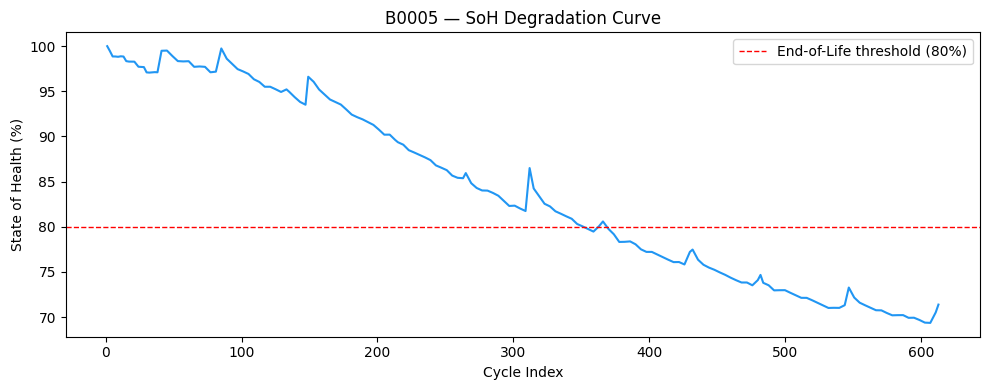

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df_b5["cycle_index"], df_b5["soh"], color="#2196F3", linewidth=1.5)
plt.axhline(80, color="red", linestyle="--", linewidth=1, label="End-of-Life threshold (80%)")
plt.xlabel("Cycle Index")
plt.ylabel("State of Health (%)")
plt.title("B0005 — SoH Degradation Curve")
plt.legend()
plt.tight_layout()
plt.show()


---
## Stage 4 — Build the Training Dataset

Process all 4 batteries and concatenate into one DataFrame.

### Why battery-level split — not random row split?

If we split rows randomly, the model sees B0018 at cycle 50 during training  
and "predicts" cycle 80 during testing. **That's data leakage** — it has already seen that battery.

In production, you'd deploy on a battery the model has never seen.  
The test split must reflect that reality.

```
Train: B0005, B0006, B0007  (~504 rows)
Test:  B0018                 (~132 rows)  ← model has never seen this battery
```


In [5]:
TRAIN_BATTERIES = ["B0005", "B0006", "B0007"]
TEST_BATTERY    = "B0018"
FEATURE_COLS    = [
    "capacity_fade_rate", "rolling_mean_capacity_10", "rolling_std_capacity_10",
    "voltage_at_end", "mean_discharge_voltage", "voltage_drop",
    "mean_temperature", "max_temperature", "discharge_duration",
]

all_dfs = []
for bid in TRAIN_BATTERIES + [TEST_BATTERY]:
    _bid, _cycles = load_mat_file(f"../data/raw/{bid}.mat")
    _discharge    = extract_discharge_cycles(_bid, _cycles)
    _df           = engineer_features(_discharge)
    all_dfs.append(_df)
    print(f"{bid}: {len(_df)} cycles | SoH {_df['soh'].min():.1f}% → {_df['soh'].max():.1f}%")

full_df  = pd.concat(all_dfs, ignore_index=True)
train_df = full_df[full_df["battery_id"].isin(TRAIN_BATTERIES)]
test_df  = full_df[full_df["battery_id"] == TEST_BATTERY]

X_train, y_train = train_df[FEATURE_COLS], train_df["soh"]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df["soh"]

print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")


B0005: 168 cycles | SoH 69.3% → 100.0%
B0006: 168 cycles | SoH 56.7% → 100.0%
B0007: 168 cycles | SoH 74.1% → 100.0%
B0018: 132 cycles | SoH 72.3% → 100.0%

X_train: (504, 9)  |  X_test: (132, 9)


---
## Stage 5 — Train, Evaluate, Log to MLflow

### What we log and why

| MLflow concept | What we store | Purpose |
|---------------|--------------|---------|
| **Parameters** | model type, n_estimators, train/test batteries | Reproducibility |
| **Metrics** | RMSE, MAE, R² | Performance tracking across runs |
| **Artifact** | trained model file | Load directly into FastAPI later |
| **Registry** | `battery-soh-predictor` v1 | Single source of truth for production model |
| **Alias** | `@production` | FastAPI loads via `models:/battery-soh-predictor@production` |

A good baseline RMSE on this dataset is **2–4% SoH** — meaning predictions are off by ~2–4 percentage points on a battery the model has never seen.


In [6]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mlflow.set_experiment("battery-soh-baseline")

with mlflow.start_run(run_name="rf-baseline-demo") as run:

    params = {
        "model_type"       : "RandomForestRegressor",
        "n_estimators"     : 100,
        "max_depth"        : "None",
        "train_batteries"  : "B0005,B0006,B0007",
        "test_battery"     : "B0018",
        "feature_set"      : "v1",
    }

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)

    mlflow.log_params(params)
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    mlflow.sklearn.log_model(
        model,
        name="model",
        registered_model_name="battery-soh-predictor",
    )

    print(f"Run ID : {run.info.run_id}")
    print(f"RMSE   : {rmse:.4f}%  ← off by ~{rmse:.1f} SoH points on unseen battery")
    print(f"MAE    : {mae:.4f}%")
    print(f"R²     : {r2:.4f}    ← model explains {r2*100:.1f}% of SoH variance")


2026/06/12 14:31:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/12 14:31:40 INFO mlflow.store.db.utils: Updating database tables
2026/06/12 14:31:42 INFO mlflow.tracking.fluent: Experiment with name 'battery-soh-baseline' does not exist. Creating a new experiment.
2026/06/12 14:31:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID : 1f2bb2f10fa54246a6be8c8efcd68dbf
RMSE   : 2.2121%  ← off by ~2.2 SoH points on unseen battery
MAE    : 1.7871%
R²     : 0.9293    ← model explains 92.9% of SoH variance


Successfully registered model 'battery-soh-predictor'.
Created version '1' of model 'battery-soh-predictor'.


In [7]:
# Promote to production using the modern alias API (MLflow 2.9+)
# Stages (Staging/Production) are deprecated — aliases are the current approach.
# FastAPI will load the model via: models:/battery-soh-predictor@production

from mlflow import MlflowClient

client = MlflowClient()
client.set_registered_model_alias("battery-soh-predictor", "production", "1")

v = client.get_model_version_by_alias("battery-soh-predictor", "production")
print(f"Registered : battery-soh-predictor v{v.version}")
print(f"Alias      : @production → v{v.version}")
print(f"Run ID     : {v.run_id[:8]}...")
print(f"\nLoad URI for FastAPI: models:/battery-soh-predictor@production")


Registered : battery-soh-predictor v1
Alias      : @production → v1
Run ID     : 1f2bb2f1...

Load URI for FastAPI: models:/battery-soh-predictor@production


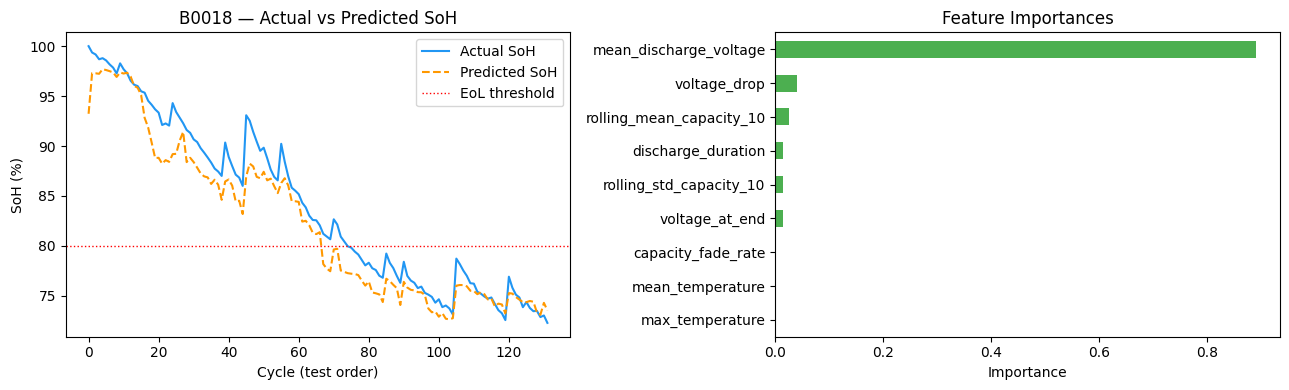


Top feature: 'mean_discharge_voltage' — makes sense given capacity is the direct SoH source


In [8]:
# Visualise: actual vs predicted SoH on test battery B0018
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: degradation curve overlay
axes[0].plot(y_test.values, label="Actual SoH", color="#2196F3", linewidth=1.5)
axes[0].plot(preds,         label="Predicted SoH", color="#FF9800", linewidth=1.5, linestyle="--")
axes[0].axhline(80, color="red", linestyle=":", linewidth=1, label="EoL threshold")
axes[0].set_title("B0018 — Actual vs Predicted SoH")
axes[0].set_xlabel("Cycle (test order)")
axes[0].set_ylabel("SoH (%)")
axes[0].legend()

# Right: feature importances
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#4CAF50")
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print(f"\nTop feature: '{importances.idxmax()}' — makes sense given capacity is the direct SoH source")


---
## Summary — What Step 1 Produced

| Deliverable | Status |
|-------------|--------|
| Raw `.mat` files loaded and parsed | ✓ |
| Discharge cycles extracted (4 batteries) | ✓ |
| ~636 rows of engineered features + SoH labels | ✓ |
| Battery-level train/test split (no leakage) | ✓ |
| Baseline RandomForest trained | ✓ |
| RMSE, MAE, R² logged in MLflow | ✓ |
| Model registered as `battery-soh-predictor` v1 | ✓ |
| Alias `@production` set | ✓ |

**Next:** Step 2 — FastAPI serving. Load `battery-soh-predictor@production` from the registry and expose a `/predict` endpoint that accepts cycle features and returns `{ soh_pct, rul_cycles, confidence }`.
